In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#suppose we have datasets here
#df = pd.read_csv('dataset path')
# x_train = df[['x_1']].to_numpy()
# y_train = df['y'].to_numpy()



def sigmoid(z):
    gg = 1 / (1 + np.exp(-z))
    return gg

def model(w, b, x:float):
    return sigmoid(w*x + b)

def logistic_cost(x, y, w, b):
    m = x.shape[1]
    total_cost = 0
    for i in range(m):
        f_wb = model(w, b, x[0,i])
        # Clip f_wb to avoid log(0)
        # f_wb = np.clip(f_wb, 1e-15, 1 - 1e-15)
        total_cost += -y[i] * np.log(f_wb) - (1 - y[i]) * np.log(1 - f_wb)
    return total_cost / m

def get_gradients(x,y,w,b):
    dj_dw = 0
    dj_db = 0
    m = x.shape[1]
    for i in range(m):
        err = model(w,b,x[0,i]) - y[i]
        dj_db += err
        dj_dw += err*x[0,i]
    return dj_dw/m , dj_db/m

def grad_descent(x,y,w,b,alpha,num_iters):
    J_hist = []
    current_J = 0
    dw = 0
    db = 0
    for j in range(num_iters):
        dw, db = get_gradients(x,y,w,b)
        w -= alpha*dw
        b -= alpha*db
        if j%math.ceil(num_iters/10) == 0:
            current_J = logistic_cost(x,y,w,b)
            J_hist.append(current_J)
            print(f"iteration: {j} | current cost: {current_J}")
    return w, b, J_hist
    

In [2]:
x_train = np.array([[ 44,  67,  43,  72,  48,  63,  78,  34,  39,  84,  76,  61,  68,  43,  70,  88,   6,  69,
   35,  54,  39,  19,  99,  31,  26,   1,  87,  12,  82,  96,  74,  23,  96,   8,  29,  28,
   23, 100,  58,  64,  96,  26,  95,  76,  69,  70,  52,  90,  59,  90,  55,  83,  77,  94,
   32,  75,  51,  45,  83,  17,  21,  70,  19,  62,  87,  73,  26,  61,  10,  95,  31,  59,
   34,  90,  43,   8,  57,  68,  48,  44,  94,  20,  39,  63,  44,  30,  85,  20,  61,  47,
   68,   3,  12,  42,  58,  67,   1,  46, 100,  97]])
y_train = np.array([
    1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 
    0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 
    1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 
    0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 
    0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1
])

# Z-score normalization:
x_mean, x_std = np.mean(x_train), np.std(x_train)
x_norm = (x_train - x_mean) / x_std

w_init = 0
b_init = 0
iters = 20000
l_rate = 0.01

# Train model on normalized data
w, b, Js = grad_descent(x_norm, y_train, w_init, b_init, l_rate, iters)
print(f"Found in grad descent | weight: {w:.4f} bias: {b:.4f}")

iteration: 0 | current cost: 0.692286800460645
iteration: 2000 | current cost: 0.49476727076381993
iteration: 4000 | current cost: 0.49384341316043
iteration: 6000 | current cost: 0.4938261653469904
iteration: 8000 | current cost: 0.49382580165031725
iteration: 10000 | current cost: 0.49382579385141134
iteration: 12000 | current cost: 0.49382579368376756
iteration: 14000 | current cost: 0.49382579368016233
iteration: 16000 | current cost: 0.49382579368008467
iteration: 18000 | current cost: 0.4938257936800832
Found in grad descent | weight: 1.4817 bias: 0.6352


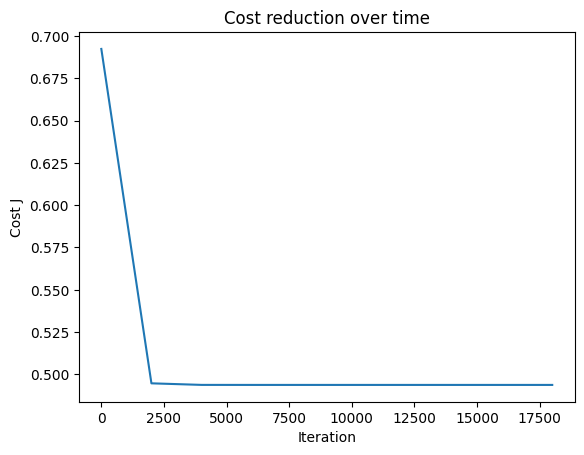

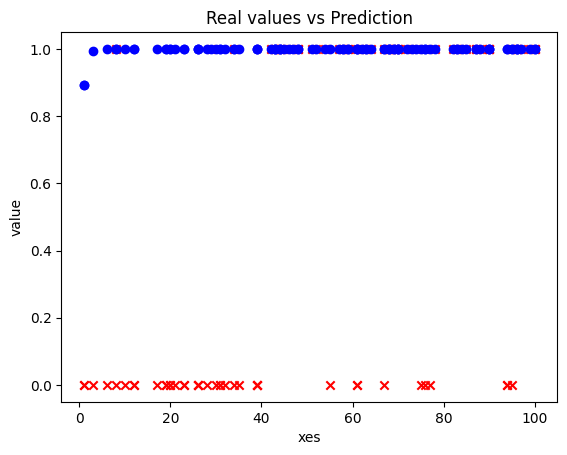

In [3]:
plt.plot(range(0, iters, math.ceil(iters/10)), Js)
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.title("Cost reduction over time")
plt.show()

plt.scatter(x_train, y_train, marker= "x", c="r")
y_predicts = sigmoid(w*x_train +b)
plt.scatter(x_train, y_predicts, c="b")
plt.xlabel("xes")
plt.ylabel("value")
plt.title("Real values vs Prediction")
plt.show()